In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../data/raw/prices_DK2_2024_08_10_2025_10_01.csv")

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
0,2024-08-10T06:00:00,2024-08-10 08:00:00,DK2,112.010002,15.01
1,2024-08-10T07:00:00,2024-08-10 09:00:00,DK2,1.490000,0.20
2,2024-08-10T08:00:00,2024-08-10 10:00:00,DK2,-22.389999,-3.00
3,2024-08-10T09:00:00,2024-08-10 11:00:00,DK2,-91.040001,-12.20
4,2024-08-10T10:00:00,2024-08-10 12:00:00,DK2,-167.830002,-22.49


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HourUTC       10000 non-null  object 
 1   HourDK        10000 non-null  object 
 2   PriceArea     10000 non-null  object 
 3   SpotPriceDKK  10000 non-null  float64
 4   SpotPriceEUR  10000 non-null  float64
dtypes: float64(2), object(3)
memory usage: 390.8+ KB


In [13]:
df.describe()

,SpotPriceDKK,SpotPriceEUR
count,10000.000000,10000.000000
mean,607.909648,81.479630
std,431.100226,57.787115
min,-447.459991,-59.959999
25%,298.839989,40.057501
50%,638.098509,85.485000
75%,825.117790,110.597498
max,6982.640137,936.309998


In [14]:
df["HourDK"] = pd.to_datetime(df["HourDK"])
df = df.sort_values("HourDK")

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceDKK,SpotPriceEUR
0,2024-08-10T06:00:00,2024-08-10 08:00:00,DK2,112.010002,15.01
1,2024-08-10T07:00:00,2024-08-10 09:00:00,DK2,1.490000,0.20
2,2024-08-10T08:00:00,2024-08-10 10:00:00,DK2,-22.389999,-3.00
3,2024-08-10T09:00:00,2024-08-10 11:00:00,DK2,-91.040001,-12.20
4,2024-08-10T10:00:00,2024-08-10 12:00:00,DK2,-167.830002,-22.49


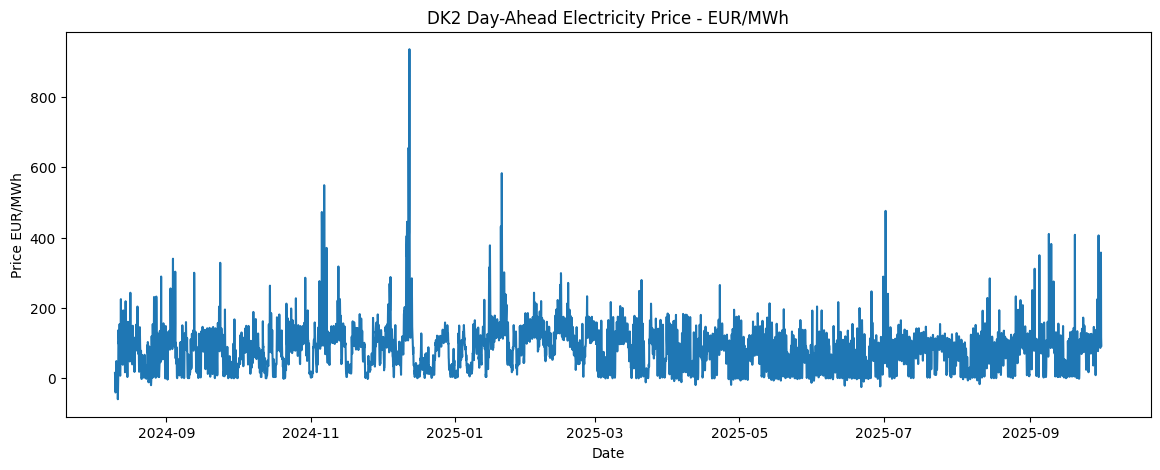

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df["HourDK"], df["SpotPriceEUR"])
plt.title("DK2 Day-Ahead Electricity Price - EUR/MWh")
plt.xlabel("Date")
plt.ylabel("Price EUR/MWh")
plt.show()

In [16]:
df["hour"] = df["HourDK"].dt.hour
df["day_of_week"] = df["HourDK"].dt.dayofweek
df["month"] = df["HourDK"].dt.month

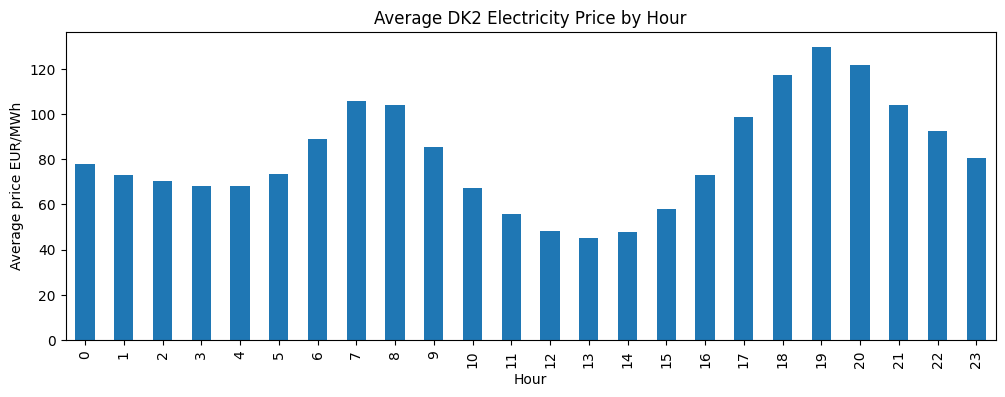

In [17]:
df.groupby("hour")["SpotPriceEUR"].mean().plot(kind="bar", figsize=(12, 4))
plt.title("Average DK2 Electricity Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Average price EUR/MWh")
plt.show()

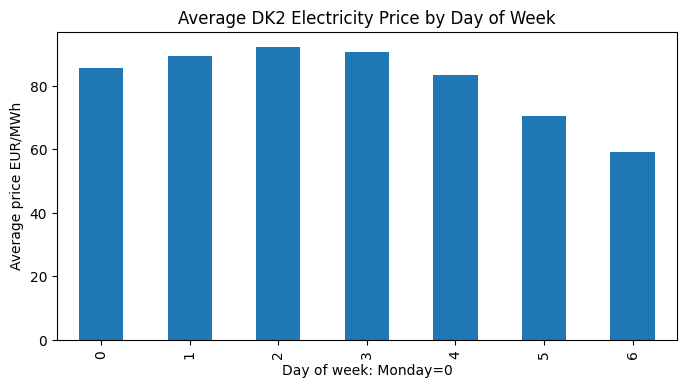

In [18]:
df.groupby("day_of_week")["SpotPriceEUR"].mean().plot(kind="bar", figsize=(8, 4))
plt.title("Average DK2 Electricity Price by Day of Week")
plt.xlabel("Day of week: Monday=0")
plt.ylabel("Average price EUR/MWh")
plt.show()